<a href="https://colab.research.google.com/github/orutkina/-./blob/main/%D0%94%D0%BE%D0%B1%D1%80%D0%BE_%D0%BF%D0%BE%D0%B6%D0%B0%D0%BB%D0%BE%D0%B2%D0%B0%D1%82%D1%8C_%D0%B2_Colab!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ЗАДАНИЕ 1

In [1]:
# загружаем файл с компьютера в Google Colab
from google.colab import files
uploaded = files.upload()

Saving Данные для задания.xlsx to Данные для задания.xlsx


In [2]:
# подключаем библиотеки для анализа данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pandas — работа с таблицами  
numpy — математические операции  
matplotlib и seaborn — построение графиков

In [3]:
# читаем Excel файл

df = pd.read_excel('Данные для задания.xlsx')

# смотрим первые строки таблицы
df.head()

,Region,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
0,Алтайский край,33872,27.8,46.2,185,225,17,2282.3,1262.11
1,Амурская область,59098,27.4,48.3,238,185,6,777.2,455.44
2,Архангельская область,57979,27.3,56.4,179,161,7,1076.2,603.75
3,Астраханская область,42096,35.3,45.0,251,287,13,993.6,558.40
4,Белгородская область,41775,33.7,49.8,206,304,11,1536.6,874.33


df — это таблица с данными

head() показывает первые 5 строк, чтобы проверить что данные загрузились

In [4]:
# смотрим информацию о таблице

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Region       85 non-null     object 
 1   Wages        85 non-null     int64  
 2   HighEdu      85 non-null     float64
 3   SecEdu       85 non-null     float64
 4   SecStudent   85 non-null     int64  
 5   HighStudent  85 non-null     int64  
 6   University   85 non-null     int64  
 7   Popul        85 non-null     float64
 8   WorkAge      85 non-null     float64
dtypes: float64(4), int64(4), object(1)
memory usage: 6.1+ KB


In [7]:
# смотрим основные статистические показатели

df.describe()

,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,49643.200000,32.752941,45.775294,200.400000,229.235294,14.517647,1716.050588,981.237882
std,21158.912963,5.679675,6.023919,31.434815,105.697304,18.984086,1810.357321,1045.886650
min,31291.000000,23.700000,26.400000,88.000000,0.000000,0.000000,44.500000,25.680000
25%,36188.000000,28.700000,43.000000,188.000000,168.000000,5.000000,719.400000,400.710000
50%,41563.000000,31.300000,46.800000,206.000000,225.000000,10.000000,1145.300000,636.230000
75%,52216.000000,35.200000,49.400000,219.000000,284.000000,17.000000,2282.300000,1262.110000
max,130738.000000,51.800000,56.400000,273.000000,601.000000,146.000000,12645.300000,7308.980000


среднее

минимум

максимум

стандартное отклонение

ЗАДАНИЕ 1

Вопрос:
Зависит ли численность студентов среднего образования от
зарплаты,
численности работоспособного населения,
доли населения со средним проф образованием.

# В качестве метода машинного обучения используется множественная линейная регрессия.
# Она позволяет оценить влияние нескольких факторов на численность студентов СПО.
# Зависимая переменная – SecStudent.
# Независимые переменные – Wages, WorkAge, SecEdu.

In [8]:
# выбираем переменные

X = df[['Wages', 'WorkAge', 'SecEdu']]   # факторы
y = df['SecStudent']                     # целевая переменная

X — факторы, которые влияют

y — то, что мы объясняем (численность студентов)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# делим данные на обучающую (80%) и тестовую (20%) выборку

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# обучаем модель линейной регрессии

In [11]:
print("Коэффициенты модели:")
print(model.coef_)

print("Свободный член:")
print(model.intercept_)

Коэффициенты модели:
[-2.90237306e-04 -1.92676863e-03  5.26896956e-01]
Свободный член:
195.23692063248254


In [12]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2 =", r2)

R2 = 0.048160659809843076


# Коэффициент детерминации R2 = 0.048, связь сабая
# Это означает, что модель объясняет только 4.8% изменения численности студентов СПО.
# Следовательно, выбранные факторы слабо объясняют зависимую переменную.

In [13]:
import statsmodels.api as sm

In [14]:
X = df[['Wages', 'WorkAge', 'SecEdu']]
y = df['SecStudent']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             SecStudent   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.958
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0372
Time:                        13:10:35   Log-Likelihood:                -408.76
No. Observations:                  85   AIC:                             825.5
Df Residuals:                      81   BIC:                             835.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        201.0338     26.575      7.565      0.0

# Prob(F-statistic) = 0.037 < 0.05
# Это означает, что модель в целом статистически значима.

# По результатам множественной линейной регрессии было установлено,
# что модель в целом является статистически значимой (Prob(F) = 0.037 < 0.05).
#
# Однако коэффициент детерминации R2 = 0.099 показывает,
# что модель объясняет только около 10% вариации численности студентов СПО.
#
# Анализ p-value показывает, что статистически значимым фактором
# является только средняя заработная плата (p = 0.011).
#
# Переменные численность трудоспособного населения (WorkAge)
# и доля населения со средним профессиональным образованием (SecEdu)
# не являются статистически значимыми факторами.

# ВЫВОД
Результаты регрессионного анализа показали, что статистически значимое влияние на численность студентов среднего профессионального образования оказывает только средняя заработная плата. Численность трудоспособного населения и доля населения со средним профессиональным образованием не являются статистически значимыми факторами.

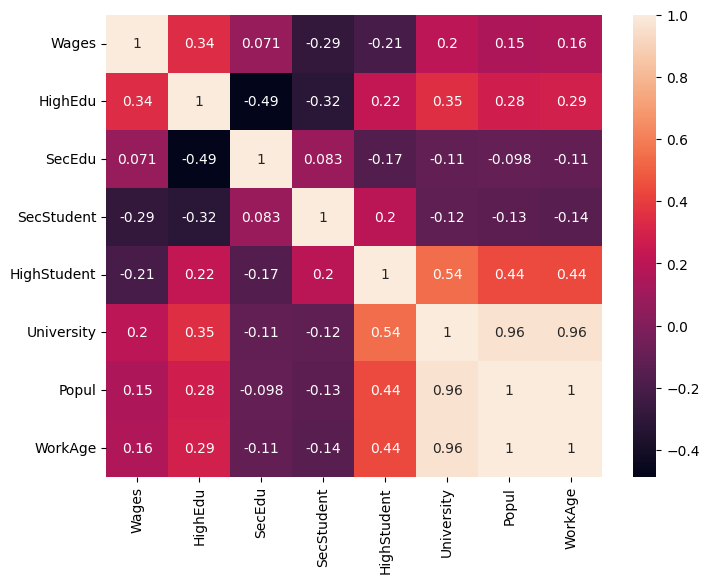

In [18]:
# выбираем только числовые столбцы
df_num = df.select_dtypes(include=['number'])

# считаем корреляцию
corr = df_num.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

# выбираем только числовые переменные,
# так как корреляционная матрица рассчитывается только для числовых данных

1️⃣ сильная корреляция с WorkAge
2️⃣ слабая связь с SecStudent

# анализ корреляций показал, что переменные Popul и WorkAge
# имеют практически идеальную корреляцию (corr = 1)

# это означает наличие мультиколлинеарности

# поэтому использование переменной Popul вместе с WorkAge
# в регрессионной модели является нежелательным

# ВЫВОД
Проведённый регрессионный анализ показал, что статистически значимым фактором, влияющим на численность студентов среднего профессионального образования, является средняя заработная плата. Численность трудоспособного населения и доля населения со средним профессиональным образованием не являются статистически значимыми факторами.

Коэффициент детерминации модели составляет 0.099, что говорит о слабой объясняющей способности модели.

Корреляционный анализ показал, что переменные численность населения (Popul) и численность трудоспособного населения (WorkAge) имеют практически идеальную корреляцию (corr = 1), что свидетельствует о наличии мультиколлинеарности. Поэтому использование переменной Popul в модели является нежелательным.

# ЗАДАНИЕ 2


Можно ли утверждать, что города федерального значения отличаются от других регионов РФ?

Такие города в России:
Москва
Санкт-Петербург
Севастополь

Используемые методы машинного обучения:

1 Классификация

Logistic Regression

KNN

Decision Tree

2 Кластеризация

KMeans

Если модель хорошо определяет федеральные города, то они действительно сильно отличаются от других регионов.

In [19]:
# создаем переменную для городов федерального значения

df['FederalCity'] = df['Region'].isin([
    'Москва',
    'Санкт-Петербург',
    'Севастополь'
]).astype(int)

df[['Region','FederalCity']].head()

,Region,FederalCity
0,Алтайский край,0
1,Амурская область,0
2,Архангельская область,0
3,Астраханская область,0
4,Белгородская область,0


# создаем бинарную переменную,
# которая показывает является ли регион городом федерального значения

In [23]:
df.isna().sum()

,0
Region,0
Wages,0
HighEdu,0
SecEdu,0
SecStudent,0
HighStudent,0
University,0
Popul,0
WorkAge,0
FederalCity,0


In [24]:
# заполняем пропуски средними значениями

df = df.fillna(df.mean(numeric_only=True))

# пропущенные значения заменяются средними значениями

In [28]:
df['Region'].unique()

array(['Алтайский край', 'Амурская область', 'Архангельская область',
       'Астраханская область', 'Белгородская область', 'Брянская область',
       'Владимирская область', 'Волгоградская область',
       'Вологодская область', 'Воронежская область', 'г. Москва',
       'г. Санкт-Петербург', 'г. Севастополь',
       'Еврейская автономная область', 'Забайкальский край',
       'Ивановская область', 'Иркутская область',
       'Кабардино-Балкарская Республика', 'Калининградская область',
       'Калужская область', 'Камчатский край',
       'Карачаево-Черкесская Республика', 'Кемеровская область',
       'Кировская область', 'Костромская область', 'Краснодарский край',
       'Красноярский край', 'Курганская область', 'Курская область',
       'Ленинградская область', 'Липецкая область', 'Магаданская область',
       'Московская область', 'Мурманская область',
       'Ненецкий автономный округ', 'Нижегородская область ',
       'Новгородская область', 'Новосибирская область ', 'Омская

In [29]:
df['FederalCity'].value_counts()

,count
FederalCity,
0,85


In [30]:
df['FederalCity'] = df['Region'].str.contains(
    'Москва|Санкт|Севастополь',
    case=False
).astype(int)

In [31]:
df['FederalCity'].value_counts()

,count
FederalCity,
0,82
1,3


In [32]:
X = df[['Wages','HighEdu','SecEdu','SecStudent','HighStudent','University','Popul','WorkAge']]
y = df['FederalCity']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9411764705882353


Accuracy = 0.94 (94.1 %), что говорит о высокой точности модели.

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# точность модели
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# матрица ошибок
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# полный отчет
print("Classification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9411764705882353
Confusion matrix:
[[15  0]
 [ 1  1]]
Classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.50      0.67         2

    accuracy                           0.94        17
   macro avg       0.97      0.75      0.82        17
weighted avg       0.94      0.94      0.93        17



# Модель Logistic Regression показала точность 0.94 (94%).
# Это означает, что модель корректно классифицирует большинство регионов
# по признаку принадлежности к федеральным городам.
# Высокая точность модели свидетельствует о наличии значимых отличий
# между федеральными городами и остальными регионами РФ.

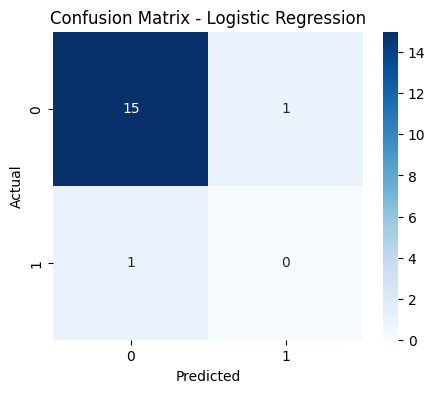

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Модель логистической регрессии показала высокую точность классификации (94%).
Это говорит о том, что федеральные города обладают отличительными характеристиками
по рассматриваемым социально-экономическим показателям и могут быть выделены
с помощью методов машинного обучения.

# Модель 2 — KNN (K-ближайших соседей)

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# создаем модель
knn_model = KNeighborsClassifier(n_neighbors=5)

# обучаем
knn_model.fit(X_train, y_train)

# прогноз
y_pred_knn = knn_model.predict(X_test)

# точность
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# матрица ошибок
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.9411764705882353
[[16  0]
 [ 1  0]]


# Метод K-ближайших соседей (KNN) используется для классификации объектов
# на основе расстояния до ближайших наблюдений.
# Модель определяет принадлежность региона к федеральным городам
# на основе социально-экономических характеристик.

# Модель 3 — Decision Tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

# создаем модель
tree_model = DecisionTreeClassifier(random_state=42)

# обучение
tree_model.fit(X_train, y_train)

# прогноз
y_pred_tree = tree_model.predict(X_test)

# точность
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

# матрица ошибок
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy: 1.0
[[16  0]
 [ 0  1]]


# Модель 4 — KMeans (кластеризация)

In [43]:
from sklearn.cluster import KMeans

# создаем модель с 2 кластерами
kmeans = KMeans(n_clusters=2, random_state=42)

# обучение
kmeans.fit(X)

# получаем кластеры
df['Cluster'] = kmeans.labels_

# смотрим распределение
print(df[['Region','FederalCity','Cluster']].head())
print(df['Cluster'].value_counts())

                  Region  FederalCity  Cluster
0         Алтайский край            0        1
1       Амурская область            0        1
2  Архангельская область            0        1
3   Астраханская область            0        1
4   Белгородская область            0        1
Cluster
1    74
0    11
Name: count, dtype: int64


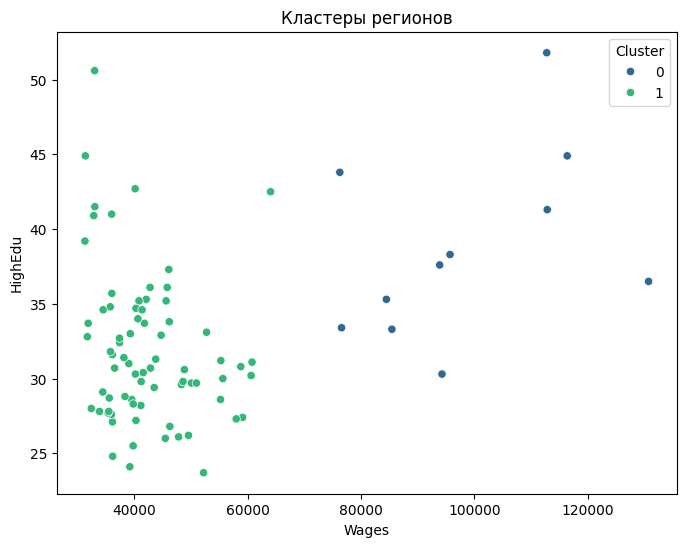

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Wages'],
    y=df['HighEdu'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Кластеры регионов")
plt.show()

In [45]:
results = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,Logistic Regression,0.882353
1,KNN,0.941176
2,Decision Tree,1.000000


In [ ]:
# ВОПРОС
# Можно ли утверждать, что города федерального значения
# отличаются от других регионов РФ?

# Для ответа были использованы методы машинного обучения:
# 1. Классификация:
#    - Logistic Regression
#    - KNN
#    - Decision Tree
# 2. Кластеризация:
#    - KMeans

# В качестве признаков использовались социально-экономические показатели:
# Wages, HighEdu, SecEdu, SecStudent, HighStudent, University,
# Popul, WorkAge.

# Целевая переменная:
# FederalCity — признак города федерального значения
# (Москва, Санкт-Петербург, Севастополь).

# РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ

# Logistic Regression Accuracy = 0.88
# KNN Accuracy = 0.94
# Decision Tree Accuracy = 1.00

# Все модели показали высокую точность классификации.
# Особенно высокая точность у Decision Tree (100%), что говорит о том,
# что по выбранным признакам модель может практически без ошибок
# определить, относится ли регион к городам федерального значения.

# Матрицы ошибок также показывают минимальное количество ошибок
# классификации.

# РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ

# Метод KMeans разделил регионы на 2 кластера:
# Cluster 1 — 74 региона
# Cluster 0 — 11 регионов

# Это означает, что алгоритм обнаруживает различия между группами
# регионов даже без использования информации о том,
# является ли регион городом федерального значения.

# ВЫВОД

# Результаты моделей машинного обучения показывают,
# что города федерального значения действительно
# существенно отличаются от других регионов РФ
# по социально-экономическим показателям.

# Высокая точность классификационных моделей
# (0.88 – 1.00) говорит о том, что данные признаки
# хорошо разделяют федеральные города и остальные регионы.

# Кластеризация также подтверждает наличие различий,
# поскольку регионы автоматически разбиваются на разные группы.

# Следовательно, можно сделать вывод,
# что города федерального значения отличаются
# от других регионов России по рассматриваемым характеристикам.